In [3]:
csv_data = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1
"""

with open("students.csv", "w", encoding="utf-8") as file:
    file.write(csv_data)

print("students.csv created successfully.")


students.csv created successfully.


========== TASK 1 - DATA EXPLORATION ==========

First 5 Rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape of Dataset:
(15, 9)

Data Types:
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Su

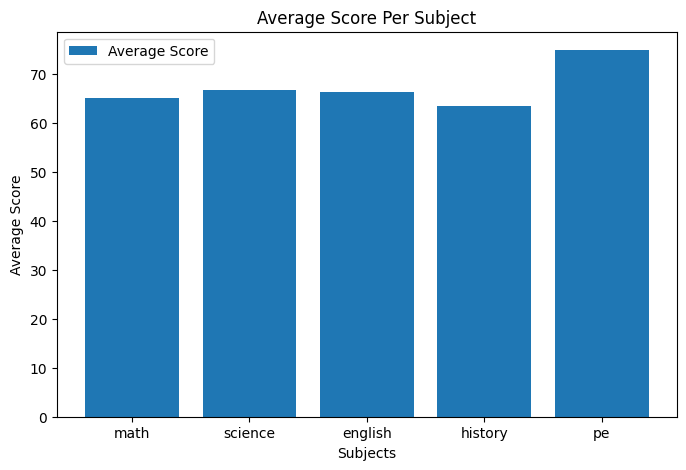

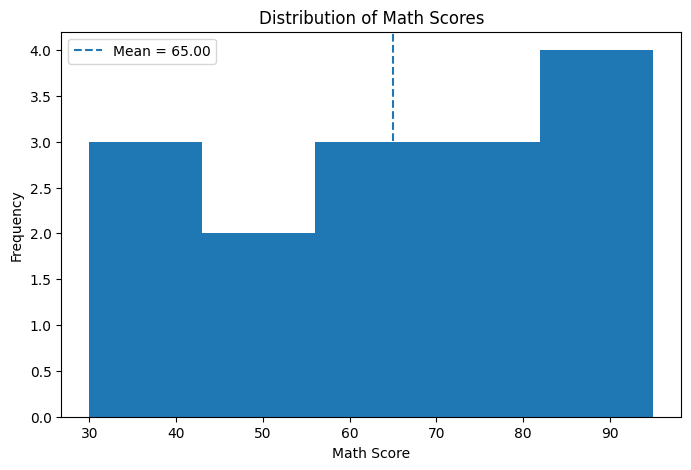

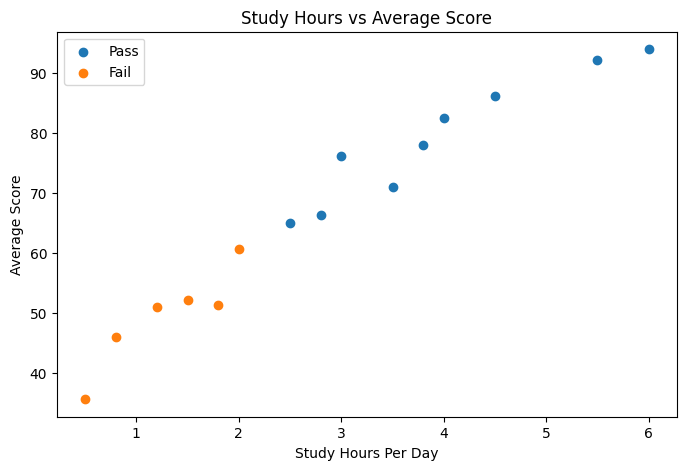

/tmp/ipykernel_36613/55920431.py:106: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


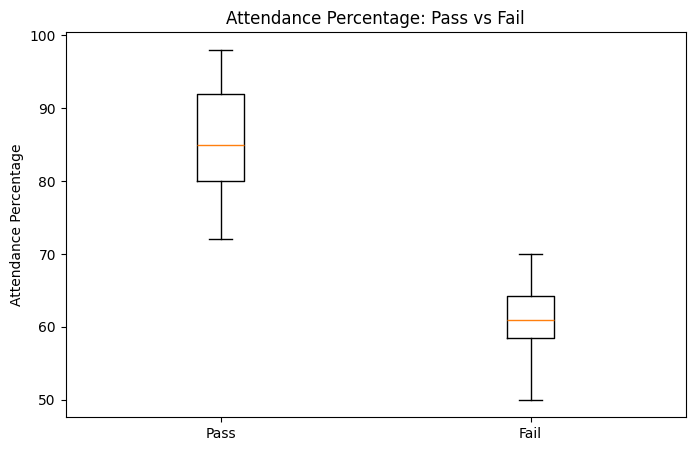

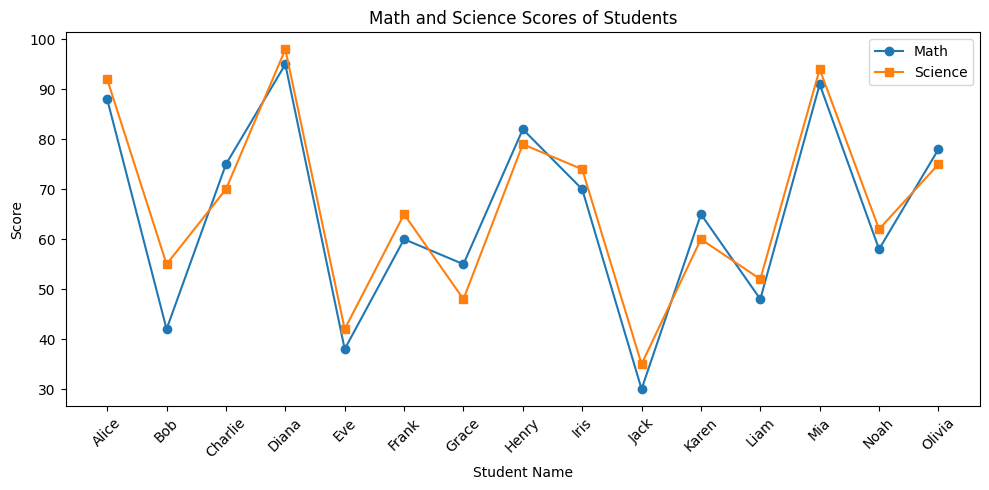


========== TASK 3 - SEABORN VISUALIZATIONS ==========



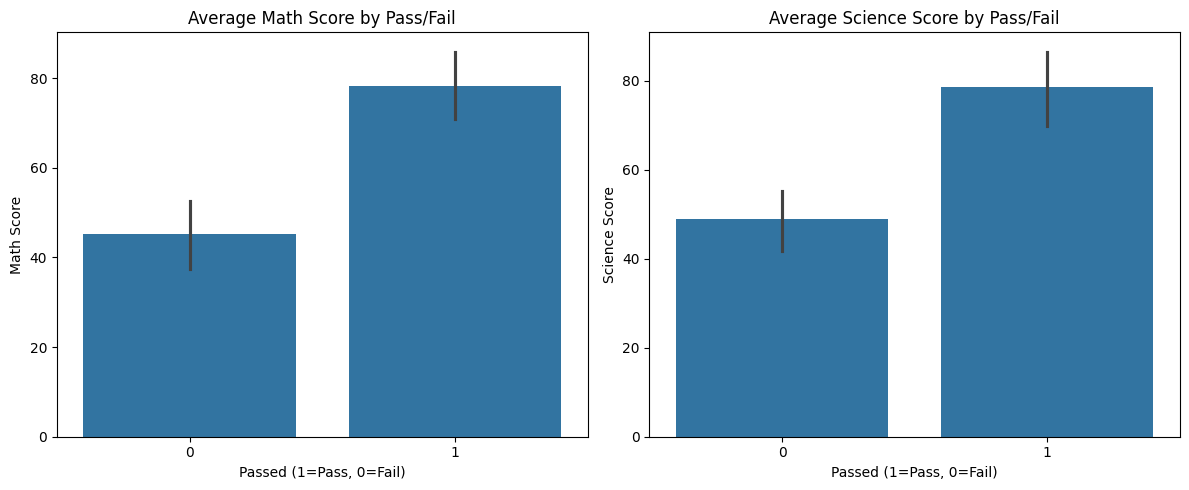

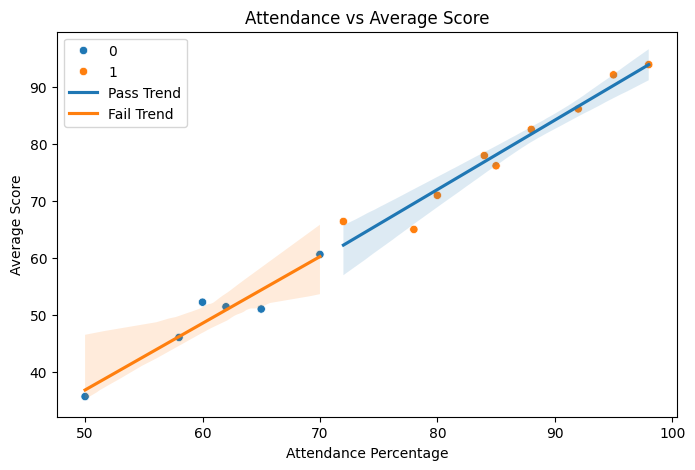


========== TASK 4 - MACHINE LEARNING ==========

Training Accuracy: 1.00
Test Accuracy: 1.00

Predictions on Test Set:
Jack | Actual: Fail | Predicted: Fail | ✅ Correct
Liam | Actual: Fail | Predicted: Fail | ✅ Correct
Alice | Actual: Pass | Predicted: Pass | ✅ Correct

Feature Coefficients (sorted by absolute importance):
english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.4750
math: 0.4379
science: 0.3230
history: 0.2629


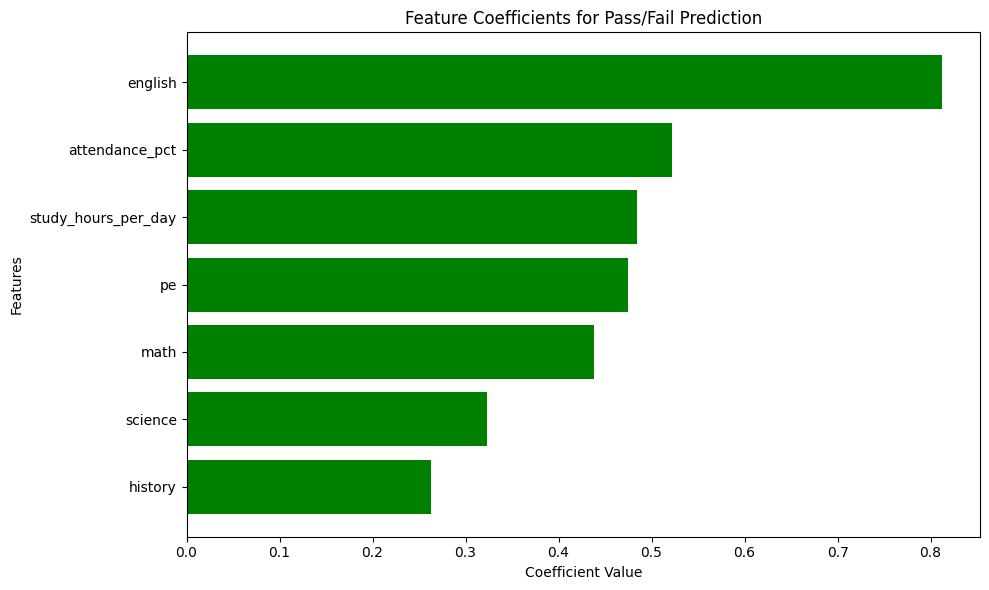


Bonus - New Student Prediction:
Predicted Result: Pass
Prediction Probabilities: Fail = 0.09, Pass = 0.91


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [4]:

#PART 4 - DATA VISUALIZATION & MACHINE LEARNING
#Theme: Student Performance Analysis & Prediction

#Install libraries if needed
!pip install pandas matplotlib seaborn scikit-learn -q

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# TASK 1 - DATA EXPLORATION WITH PANDAS

print("========== TASK 1 - DATA EXPLORATION ==========\n")

df = pd.read_csv("students.csv")

print("First 5 Rows:")
print(df.head())

print("\nShape of Dataset:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nSummary Statistics:")
print(df.describe())

print("\nPass / Fail Counts:")
print(df['passed'].value_counts())

subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("\nAverage Scores for Passing Students:")
print(df[df['passed'] == 1][subject_cols].mean())

print("\nAverage Scores for Failing Students:")
print(df[df['passed'] == 0][subject_cols].mean())

df['overall_avg'] = df[subject_cols].mean(axis=1)
top_student = df.loc[df['overall_avg'].idxmax()]

print("\nStudent with Highest Overall Average:")
print(f'{top_student["name"]} - {top_student["overall_avg"]:.2f}')

#TASK 2 - DATA VISUALIZATION WITH MATPLOTLIB

print("\n========== TASK 2 - MATPLOTLIB VISUALIZATIONS ==========\n")

df['avg_score'] = df[subject_cols].mean(axis=1)

# Plot 1 - Bar Chart
avg_subject_scores = df[subject_cols].mean()

plt.figure(figsize=(8, 5))
plt.bar(avg_subject_scores.index, avg_subject_scores.values)
plt.title("Average Score Per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.legend(["Average Score"])
plt.savefig("plot1_bar.png")
plt.show()

# Plot 2 - Histogram
plt.figure(figsize=(8, 5))
plt.hist(df['math'], bins=5)
mean_math = df['math'].mean()
plt.axvline(mean_math, linestyle='dashed', label=f"Mean = {mean_math:.2f}")
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("plot2_histogram.png")
plt.show()

#Plot 3 - Scatter Plot
plt.figure(figsize=(8, 5))
pass_students = df[df['passed'] == 1]
fail_students = df[df['passed'] == 0]

plt.scatter(pass_students['study_hours_per_day'], pass_students['avg_score'], label='Pass')
plt.scatter(fail_students['study_hours_per_day'], fail_students['avg_score'], label='Fail')

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()

#Plot 4 - Box Plot
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.figure(figsize=(8, 5))
plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])
plt.title("Attendance Percentage: Pass vs Fail")
plt.ylabel("Attendance Percentage")
plt.savefig("plot4_boxplot.png")
plt.show()

#Plot 5 - Line Plot
plt.figure(figsize=(10, 5))
plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='s', label='Science')
plt.title("Math and Science Scores of Students")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("plot5_line.png")
plt.show()

#TASK 3 -DATA VISUALIZATION WITH SEABORN

print("\n========== TASK 3 - SEABORN VISUALIZATIONS ==========\n")

#Plot 6 - Seaborn Bar Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math')
plt.title("Average Math Score by Pass/Fail")
plt.xlabel("Passed (1=Pass, 0=Fail)")
plt.ylabel("Math Score")

plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science')
plt.title("Average Science Score by Pass/Fail")
plt.xlabel("Passed (1=Pass, 0=Fail)")
plt.ylabel("Science Score")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()

# Plot 7 - Seaborn Scatter + Regression
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

sns.regplot(data=df[df['passed'] == 1], x='attendance_pct', y='avg_score', scatter=False, label='Pass Trend')
sns.regplot(data=df[df['passed'] == 0], x='attendance_pct', y='avg_score', scatter=False, label='Fail Trend')

plt.title("Attendance vs Average Score")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot7_seaborn_scatter.png")
plt.show()

# Comment:
# Seaborn made some plots easier and more visually polished compared to Matplotlib.
# Matplotlib gave more manual control, but Seaborn required less code for grouped visualizations.

# TASK 4 - MACHINE LEARNING WITH SCIKIT-LEARN

print("\n========== TASK 4 - MACHINE LEARNING ==========\n")

feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[feature_cols]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

train_accuracy = model.score(X_train_scaled, y_train)
print(f"Training Accuracy: {train_accuracy:.2f}")

y_pred = model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.2f}\n")

print("Predictions on Test Set:")
test_names = df.loc[X_test.index, 'name']

for name, actual, predicted in zip(test_names, y_test, y_pred):
    status = "✅ Correct" if actual == predicted else "❌ Wrong"
    actual_label = "Pass" if actual == 1 else "Fail"
    predicted_label = "Pass" if predicted == 1 else "Fail"
    print(f"{name} | Actual: {actual_label} | Predicted: {predicted_label} | {status}")

# Feature Importance
print("\nFeature Coefficients (sorted by absolute importance):")
coefficients = model.coef_[0]
feature_importance = list(zip(feature_cols, coefficients))
feature_importance_sorted = sorted(feature_importance, key=lambda x: abs(x[1]), reverse=True)

for feature, coef in feature_importance_sorted:
    print(f"{feature}: {coef:.4f}")

#Feature Importance Plot
features = [item[0] for item in feature_importance_sorted]
coefs = [item[1] for item in feature_importance_sorted]
colors = ['green' if coef > 0 else 'red' for coef in coefs]

plt.figure(figsize=(10, 6))
plt.barh(features, coefs, color=colors)
plt.title("Feature Coefficients for Pass/Fail Prediction")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#Bonus - Predict for New Student
print("\nBonus - New Student Prediction:")
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]
new_student_scaled = scaler.transform(new_student)

prediction = model.predict(new_student_scaled)[0]
probability = model.predict_proba(new_student_scaled)[0]

predicted_label = "Pass" if prediction == 1 else "Fail"
print(f"Predicted Result: {predicted_label}")
print(f"Prediction Probabilities: Fail = {probability[0]:.2f}, Pass = {probability[1]:.2f}")
